# Visual laboratory: tensor products and contraction

Coordinate arrays make multilinear operations computable. They are representations of the underlying tensor relationships, not their complete definition.

## An outer product builds an order-two object

For $\vec u=(1,2)$ and $\vec v=(3,-1)$,

$$
(\vec u\vec v^{\mathsf T})_{ij}=u_i v_j.
$$

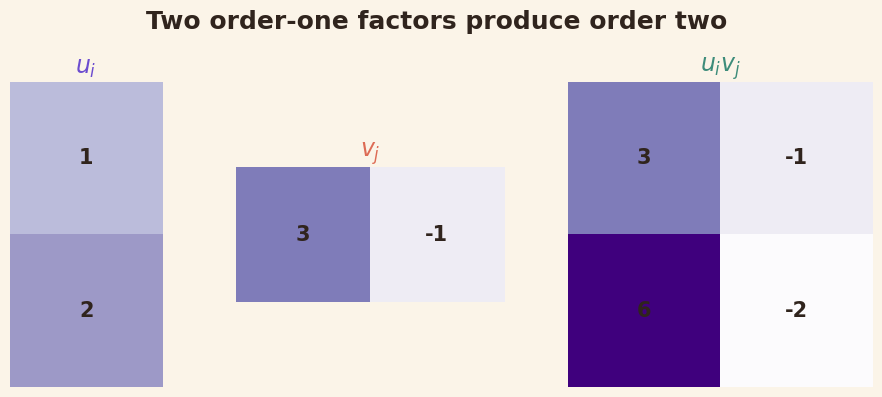

In [1]:
import numpy as np
import matplotlib.pyplot as plt

paper='#fbf4e8'; ink='#30241d'; purple='#6c4ccf'; coral='#dd6b55'; teal='#3d8c7a'
u=np.array([1.,2.]); v=np.array([3.,-1.]); outer=np.outer(u,v)
fig,axes=plt.subplots(1,3,figsize=(10,4),facecolor=paper,gridspec_kw={'width_ratios':[1,1,1.5]})
items=[(u.reshape(-1,1),r'$u_i$',purple),(v.reshape(1,-1),r'$v_j$',coral),(outer,r'$u_i v_j$',teal)]
for ax,(arr,title,color) in zip(axes,items):
    ax.set_facecolor(paper); ax.imshow(arr,cmap='Purples',vmin=-2,vmax=6,aspect='equal')
    for (i,j),val in np.ndenumerate(arr): ax.text(j,i,f'{val:g}',ha='center',va='center',color=ink,fontsize=15,weight='bold')
    ax.set_title(title,color=color,fontsize=17,weight='bold'); ax.set_xticks([]); ax.set_yticks([])
    for s in ax.spines.values(): s.set_visible(False)
fig.suptitle('Two order-one factors produce order two',color=ink,fontsize=18,weight='bold')
fig.tight_layout(); plt.show()

## Contraction removes one paired index

Let $T_{ijk}$ be represented by two $2\times2$ slices and let $x_k$ be a vector. Contracting the index $k$ gives

$$
C_{ij}=\sum_k T_{ijk}x_k.
$$

An order-three component array and an order-one vector produce an order-two component array.

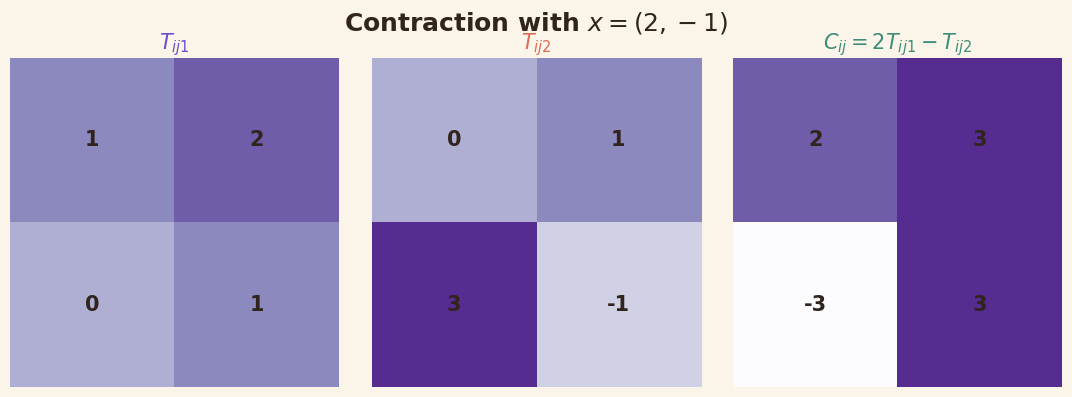

In [2]:
T=np.array([[[1.,0.],[2.,1.]],[[0.,3.],[1.,-1.]]])
x=np.array([2.,-1.])
C=np.tensordot(T,x,axes=([2],[0]))
slices=[T[:,:,0],T[:,:,1],C]
titles=[r'$T_{ij1}$',r'$T_{ij2}$',r'$C_{ij}=2T_{ij1}-T_{ij2}$']
colors=[purple,coral,teal]
fig,axes=plt.subplots(1,3,figsize=(11,4),facecolor=paper)
for ax,arr,title,color in zip(axes,slices,titles,colors):
    ax.set_facecolor(paper); ax.imshow(arr,cmap='Purples',vmin=-3,vmax=4)
    for (i,j),val in np.ndenumerate(arr): ax.text(j,i,f'{val:g}',ha='center',va='center',color=ink,fontsize=15,weight='bold')
    ax.set_title(title,color=color,fontsize=15,weight='bold'); ax.set_xticks([]); ax.set_yticks([])
    for s in ax.spines.values(): s.set_visible(False)
fig.suptitle(r'Contraction with $x=(2,-1)$',color=ink,fontsize=18,weight='bold')
fig.tight_layout(); plt.show()